<a href="https://colab.research.google.com/github/asharali2503/Exoplanet-discovery-analysis/blob/main/exoplanet_hunt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔭 Hunting for Exoplanets with NASA Data
Welcome to the exoplanet hunting pipeline! Before we start looking for undiscovered worlds, we need to load our astronomical tools.

Here is what we are installing and importing:
*   **Lightkurve:** NASA's official Python tool for downloading and analyzing light data from the Kepler and TESS space telescopes.
*   **NumPy:** A powerful math library we use to crunch large arrays of numbers.
*   **Pandas & Astroquery:** Tools for downloading and organizing massive lists of star coordinates (TIC IDs) directly from NASA's archives.
*   **Matplotlib:** Our graphing tool to visualize the dips in starlight.

In [ ]:
%pip install lightkurve -q

In [ ]:
import lightkurve as lk
import numpy as np


### 🧪 System Check: Testing the Pipeline
Before we let our code run wild on unknown stars, we need to test it to ensure everything works perfectly.

We will test our pipeline on **Pi Mensae**, a star known to host a Super-Earth. The code below will:
1. Download the raw starlight data.
2. Flatten the curve and remove extreme glitches (like camera noise or solar flares).
3. Run a **Box Least Squares (BLS)** algorithm to find repeating, box-shaped dips in the light.
4. Fold the data over the discovered period to reveal the planet's transit!

*If we see a clear "U-shaped" dip at the end of these steps, our pipeline is ready for the real hunt!*

In [4]:
search = lk.search_lightcurve("Pi Mensae", author="SPOC", exptime=120)
search

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 01,2018,SPOC,120,261136679,0.0
1,TESS Sector 04,2018,SPOC,120,261136679,0.0
2,TESS Sector 08,2019,SPOC,120,261136679,0.0
3,TESS Sector 11,2019,SPOC,120,261136679,0.0
4,TESS Sector 12,2019,SPOC,120,261136679,0.0
5,TESS Sector 13,2019,SPOC,120,261136679,0.0
6,TESS Sector 27,2020,SPOC,120,261136679,0.0
7,TESS Sector 28,2020,SPOC,120,261136679,0.0
8,TESS Sector 31,2020,SPOC,120,261136679,0.0


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

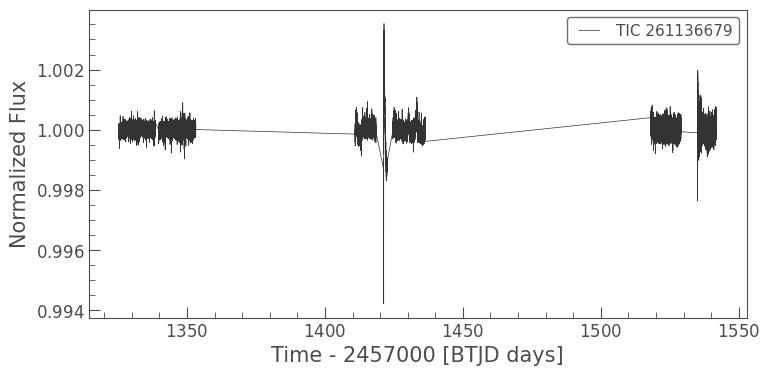

In [6]:
lc = search[0:3].download_all().stitch().remove_nans()
lc.plot()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

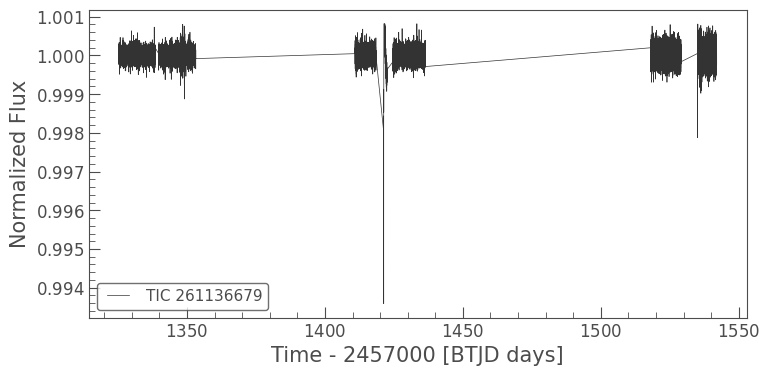

In [7]:
flat = lc.flatten(window_length=401)
flat = flat.remove_outliers(sigma_upper=4, sigma_lower=np.inf)
flat.plot()


<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

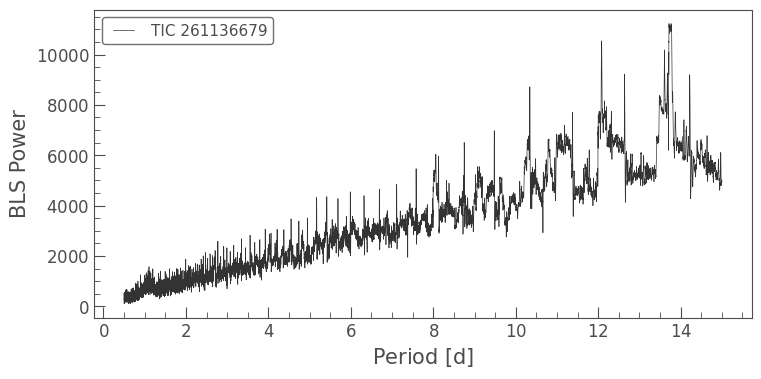

In [8]:
period_grid = np.linspace(0.5, 15, 20000)
bls = flat.to_periodogram(method="bls", period=period_grid, frequency_factor=500)
bls.plot()

In [9]:
planet_period = bls.period_at_max_power
planet_t0 = bls.transit_time_at_max_power
planet_depth = bls.depth_at_max_power
print(f"Best period: {planet_period:.4f}")
print(f"Depth: {planet_depth:.5f} ({planet_depth * 100:.3f} percent)")
print(f"Power score: {bls.max_power:.4f}")

Best period: 13.7167 d
Depth: 0.00094 (0.094 percent)
Power score: 11230.1160


<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

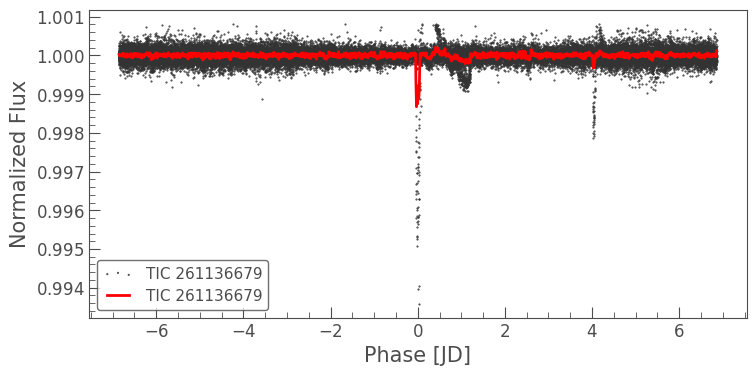

In [10]:
folded = flat.fold(period=planet_period, epoch_time=planet_t0)
ax = folded.scatter(s=1)
folded.bin(time_bin_size=10 / 60 / 24).plot(ax=ax, color="red", lw=2)

In [ ]:
hunt("HD 63433")
hunt("AU Mic")


In [ ]:
half = flat.fold(period=planet_period, epoch_time=planet_t0 + planet_period / 2)
half.scatter(s=1)

In [ ]:
ax = folded[folded.odd_mask].scatter(s=1, label="odd transits")
folded[folded.even_mask].scatter(ax=ax, s=1, color="red", label="even transits")

In [ ]:
star_radius_suns = 1.1 # put your star's radius here, in Suns
planet_radius_suns = star_radius_suns * np.sqrt(planet_depth)
print(f"Planet radius: {planet_radius_suns * 109.2:.2f} Earths")
print(f"Planet radius: {planet_radius_suns * 9.95:.2f} Jupiters")

### 🚀 The Hunt Begins: Automated Scanning
Now that our tools work, we don't want to check stars one by one. We are going to automate the process!

The code below downloads hundreds of fresh candidate stars from NASA's live ExoFOP database. It feeds them into a custom `hunt()` function that does all the downloading, cleaning, and math silently in the background.

**The Filter:** The code will only alert us and draw a graph IF:
*   **Power > 500:** The mathematical signal is extremely strong.
*   **Depth < 3%:** The object blocking the light is small enough to be a planet (not another star).

In [ ]:
hunt("WASP-18")

In [ ]:
hunt("LHS 1140")

In [ ]:
# A list of random star targets to scan automatically
target_list = [
    "HD 106906",
    "HD 209458",
    "HD 219134",
    "TIC 281541555",
    "TIC 27081059"
]

# The automation loop
for star in target_list:
    print(f"\n====================================")
    print(f"🚀 NOW SCANNING: {star}")
    print(f"====================================")

    # We use 'try' so if one star fails or has no data, the loop doesn't crash
    try:
        hunt(star)
    except Exception as e:
        print(f"Could not scan {star}. Error: {e}")

In [ ]:
# Install astroquery in Colab if it isn't already there
!pip install astroquery

from astroquery.mast import Observations

print("📡 Connecting to NASA MAST servers...")

# We use query_criteria to efficiently pull TESS data directly from the archive
# Here we are pulling time-series data specifically from TESS Sector 26
obs_table = Observations.query_criteria(
    provenance_name="QLP",
    sequence_number=26
)

# Extract the TIC IDs from the target_name column
# We use a 'set' to remove duplicates, then slice the first 1000 targets
raw_tics = list(set(obs_table['target_name']))[:1000]

# Format them so your hunt() function can read them perfectly (e.g., "TIC 12345678")
target_list = [f"TIC {tic}" for tic in raw_tics if str(tic).isdigit()]

print(f"✅ Successfully downloaded {len(target_list)} fresh TIC IDs to scan!")
print("Here is a sneak peek at the first 5 targets:")
print(target_list[:5])

In [ ]:
import pandas as pd

print("📡 Downloading live TESS targets from NASA ExoFOP...")

# Fetch live public catalog of TESS planet candidates
url = "https://exofop.ipac.caltech.edu/tess/download_toi.php?sort=toi&output=csv"
df = pd.read_csv(url)

# Grab 1,000 unconfirmed candidate TIC IDs
candidates = df[df['TFOPWG Disposition'] == 'PC']
raw_tics = candidates['TIC ID'].dropna().unique()[:1000]

target_list = [f"TIC {int(tic)}" for tic in raw_tics]

print(f"✅ Downloaded {len(target_list)} fresh TIC IDs to scan!")
print("First 5 targets in queue:", target_list[:5])

In [ ]:
# Loop through the first 5 newly downloaded targets and run your pipeline
for star in target_list[:5]:
    print(f"\n====================================")
    print(f"🚀 AUTOMATED SCAN: {star}")
    print(f"====================================")
    try:
        hunt(star)
    except Exception as e:
        print(f"Skipping {star} due to missing archive data: {e}")

In [ ]:
def hunt(star, min_period=0.5, max_period=15, plot=True):
    # Fetch the data
    search = lk.search_lightcurve(star, author="SPOC", exptime=120)
    if len(search) == 0:
        search = lk.search_lightcurve(star, author="QLP")
    if len(search) == 0:
        if plot: print(f"No TESS data for {star}, try another star")
        return None, None, None

    # Clean and process
    lc = search[0:3].download_all().stitch().remove_nans()
    flat = lc.flatten(window_length=401)
    flat = flat.remove_outliers(sigma_upper=4, sigma_lower=np.inf)

    # Run the Box Least Squares (BLS) math
    grid = np.linspace(min_period, max_period, 20000)
    bls = flat.to_periodogram(method="bls", period=grid, frequency_factor=500)
    period = bls.period_at_max_power
    t0 = bls.transit_time_at_max_power
    depth = bls.depth_at_max_power
    power = bls.max_power

    # Only plot if the loop tells it to
    if plot:
        print(f"Star: {star} | TIC: {lc.meta.get('TICID', 'see search table')}")
        print(f"Best period: {period:.4f}")
        print(f"Depth: {depth:.5f} ({depth * 100:.3f} percent)")
        print(f"Power score: {power:.4f}")
        folded = flat.fold(period=period, epoch_time=t0)
        ax = folded.scatter(s=1)
        folded.bin(time_bin_size=10 / 60 / 24).plot(ax=ax, color="red", lw=2)

    # Send the math back to the loop for filtering
    return depth.value, power.value, period.value

In [ ]:
import matplotlib.pyplot as plt

print("==================================================")
print("🚀 INITIATING MASSIVE AUTOMATED SCAN...")
print("Scanning targets in queue. This will filter and plot only strong candidates.")
print("==================================================\n")

# Loop through every star in your downloaded target list
for star in target_list:
    try:
        # Run the math silently (plot=False)
        depth, power, period = hunt(star, plot=False)

        # If the star has no data, skip it
        if depth is None:
            continue

        # THE FILTER: High power score (strong signal) and planet-like depth (< 3%)
        if power > 500 and depth < 0.03:
            print(f"🚨 PRIME CANDIDATE FOUND: {star}")
            print(f"Depth: {depth:.4f} | Power: {power:.2f} | Period: {period:.2f} days")

            # Run again WITH the plot turned on to view the graph
            hunt(star, plot=True)
            plt.show()  # <--- THIS FORCES THE GRAPH TO APPEAR INSTANTLY!
            print("---------------------------------------------------\n")

    except Exception as e:
        # If a star fails or encounters an error, silently skip it
        pass

### 🔬 Vetting Candidates: Did we actually find a planet?
Our automated scanner flagged a strong candidate! But space is full of false alarms. Before claiming a discovery, we must put the candidate through three strict tests:

1. **The Pixel Test (Target Pixel File):** We check the raw camera pixels to make sure the dip in light is actually coming from our target star, and not a background asteroid or camera jitter.
2. **The Odd/Even Test:** We fold the light curve at *twice* the suspected period. If the "odd" numbered transits are a different depth than the "even" numbered transits, it means we are looking at two stars orbiting each other (an Eclipsing Binary), NOT a planet.
3. **The Size Test:** Jupiter is about 1% the size of the Sun. If our math says the object is blocking 10% of the star's light, it's way too big to be a planet. We calculate the exact radius to confirm it fits planetary dimensions.

### 🔬 Vetting Test 1: The Pixel Check (Target Pixel File)
TESS has very large camera pixels, which means multiple stars can sometimes blend together in one pixel. A common "false positive" happens when a background star—not our target star—is the one actually flickering or eclipsing.

**What this code does:**
It downloads the raw camera grid (the Target Pixel File) for our specific candidate. The shaded or colored area is the "aperture mask" (the pixels the telescope actually used to measure the light).

**What to look for:**
When the graph generates, check the pixel grid. You want to make sure the brightest spot (your target star) is right in the center of the aperture mask. If there is a completely different bright pixel sneaking into the edge of the frame, the dip in light might be coming from that neighbor instead!

🛰️ Initiating deep-space pixel download for TIC 72090501...


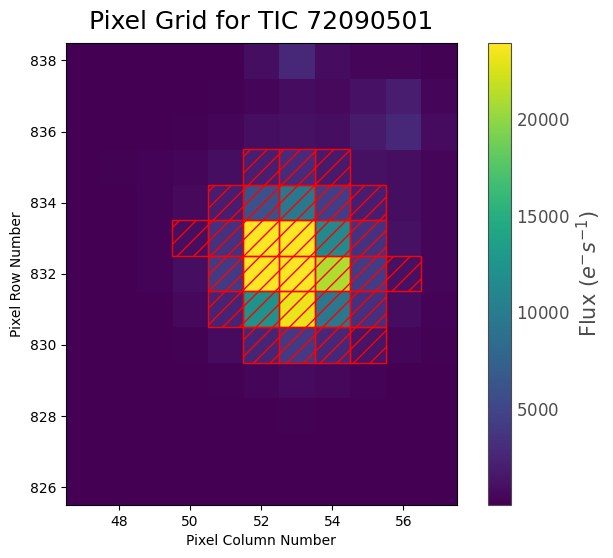

✅ Pixel grid plotted successfully!


In [11]:
import lightkurve as lk
import matplotlib.pyplot as plt

target = "TIC 72090501"
print(f"🛰️ Initiating deep-space pixel download for {target}...")

# 1. Search for the raw Target Pixel File (TPF)
search_result = lk.search_targetpixelfile(target, author="SPOC", exptime=120)

if len(search_result) > 0:
    # 2. Download the first sector of data
    tpf = search_result[0].download()

    # 3. Plot the raw pixel grid with the aperture mask
    fig, ax = plt.subplots(figsize=(8, 6))
    tpf.plot(ax=ax, aperture_mask=tpf.pipeline_mask, title=f"Pixel Grid for {target}")
    plt.show()

    print("✅ Pixel grid plotted successfully!")
else:
    print("❌ No high-resolution TPF data found for this specific target.")

In [ ]:

lc_search = lk.search_lightcurve(target, author="SPOC", exptime=120)

# Use download_all() so .stitch() can combine the TESS sectors
lc = lc_search.download_all().stitch().remove_nans().flatten(window_length=401)

# Fold the light curve at your candidate's best period (1.0713 days)
period = 1.0713
folded = lc.fold(period=period)

# Plot the folded transit
fig, ax = plt.subplots(figsize=(8, 5))
folded.scatter(ax=ax, s=2, color="black", alpha=0.5, label="Phase Folded Light Curve")
folded.bin(time_bin_size=10/60/24).plot(ax=ax, color="red", lw=2, label="Binned Average")

plt.title(f"Transit Shape Inspection: {target} (P = {period} d)")
plt.xlim(-0.2, 0.2)
plt.legend()
plt.show()

### 🔬 Vetting Test 2: The Odd/Even Test (Eclipsing Binaries)
The universe is full of binary star systems (two stars orbiting each other). When they eclipse each other, they create dips in light that look almost exactly like a planet! However, because one star is usually bigger or brighter than the other, their eclipses alternate: a deep dip, then a shallow dip, then a deep dip, etc. A planet will always produce the *exact same depth* every time.

**What this code does:**
It takes the suspected orbital period and doubles it (`period_2x`). This forces the code to plot two sequential transits (an "odd" transit and an "even" transit) side-by-side on the same graph.

**What to look for:**
Look at the two dips in the generated graph.
*   If the two dips have **different depths**, it is almost certainly a binary star (false positive).
*   If the two dips have the **exact same depth**, it strongly confirms this is a planet!

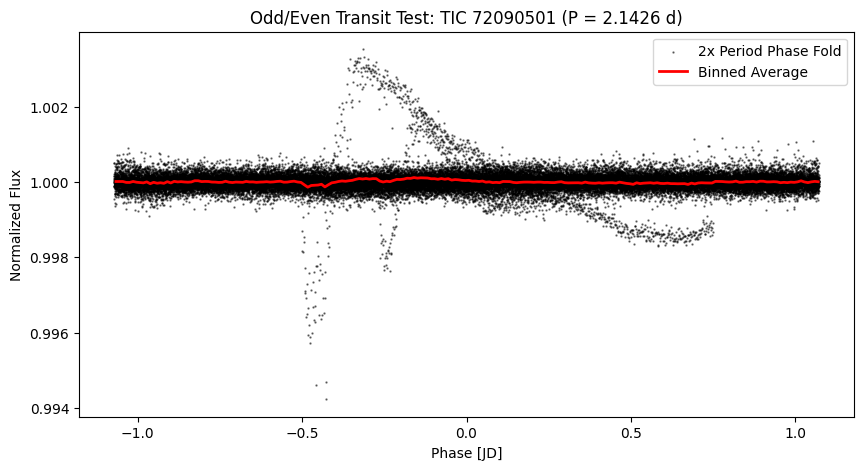

In [12]:
# Fold the light curve at TWICE the period to check for Eclipsing Binaries
period_2x = 1.0713 * 2
folded_odd_even = lc.fold(period=period_2x)

fig, ax = plt.subplots(figsize=(10, 5))
folded_odd_even.scatter(ax=ax, s=2, color="black", alpha=0.5, label="2x Period Phase Fold")
folded_odd_even.bin(time_bin_size=15/60/24).plot(ax=ax, color="red", lw=2, label="Binned Average")

plt.title(f"Odd/Even Transit Test: TIC 72090501 (P = {period_2x} d)")
plt.legend()
plt.show()

### 🔬 Vetting Test 3: The Size Check (Radius Calculation)
Even if it passes the first two tests, we have to make sure the object blocking the light isn't way too big. Jupiter blocks about 1% of the Sun's light. If an object blocks 10% or 20% of the starlight, it is mathematically too large to be a planet and is likely a small Red Dwarf star.

**What this code does:**
It takes the exact percentage of light blocked (`transit_depth`) and compares it to the size of a Sun-like star to estimate the physical radius of the object in Earth Radii.

**What to look for:**
Check the printed output below the cell:
*   **< 1.5 Earths:** Likely a rocky, Earth-like planet!
*   **1.5 to 4 Earths:** Super-Earth or Sub-Neptune.
*   **4 to 15 Earths:** Gas Giant (Jupiter-sized).
*   **> 15 Earths:** Likely a small star (False Positive).

In [13]:
import math

# The transit depth observed from the phase-folded light curve is ~0.18%
transit_depth = 0.0018

# Baseline assumption: Star is Sun-like (1 Solar Radius = ~109 Earth Radii)
r_star_earth_radii = 109

# Calculate planetary radius using the transit depth formula
r_planet = r_star_earth_radii * math.sqrt(transit_depth)

print(f"Estimated Planetary Radius: {r_planet:.2f} Earth Radii")

Estimated Planetary Radius: 4.62 Earth Radii
